# Mutual Information

Mutual Information (MI) is a filter-based feature selection technique
that measures how much information a feature provides about the target.

It measures the dependency between two variables.

A higher Mutual Information score means that knowing the feature provides
more information about the target.

Unlike correlation, Mutual Information can detect both:

- Linear relationships
- Non-linear relationships

## Intuition

Suppose we have:

Feature A → Strongly related to Target

Feature B → Weakly related to Target

Feature C → No relationship with Target

Mutual Information will generally give:

Feature A → High MI score

Feature B → Lower MI score

Feature C → Near-zero MI score

Therefore, we can rank features according to their Mutual Information
scores and select the most informative features.

## Mutual Information vs Correlation

Correlation mainly measures linear relationships.

Mutual Information can detect more general statistical dependencies,
including non-linear relationships.

Correlation:

Feature → Linear Relationship → Target

Mutual Information:

Feature → Any Statistical Dependency → Target

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, 300),
    "Income": np.random.randint(20000, 100000, 300),
    "Experience": np.random.randint(0, 20, 300),
    "Random_Feature": np.random.randn(300),
    "Target": np.random.randint(0, 2, 300)
})

df.head()

,Age,Income,Experience,Random_Feature,Target
0,56,59790,16,0.086590,1
1,46,25600,13,-0.155677,0
2,32,60764,14,1.167782,0
3,25,94543,0,0.254421,1
4,38,65714,2,0.337603,0


In [2]:
X = df.drop(columns="Target")
y = df["Target"]

X.head()

,Age,Income,Experience,Random_Feature
0,56,59790,16,0.086590
1,46,25600,13,-0.155677
2,32,60764,14,1.167782
3,25,94543,0,0.254421
4,38,65714,2,0.337603


## Calculating Mutual Information

Scikit-learn provides:

`mutual_info_classif`

for calculating Mutual Information between features and a categorical
target.

A higher score indicates a stronger dependency between the feature and
the target.

In [3]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_scores

array([0.0154028 , 0.03613817, 0.        , 0.00599779])

In [4]:
mi_results = pd.DataFrame({
    "Feature": X.columns,
    "Mutual_Information": mi_scores
})

mi_results

,Feature,Mutual_Information
0,Age,0.015403
1,Income,0.036138
2,Experience,0.000000
3,Random_Feature,0.005998


In [5]:
mi_results = mi_results.sort_values(
    by="Mutual_Information",
    ascending=False
)

mi_results

,Feature,Mutual_Information
1,Income,0.036138
0,Age,0.015403
3,Random_Feature,0.005998
2,Experience,0.000000


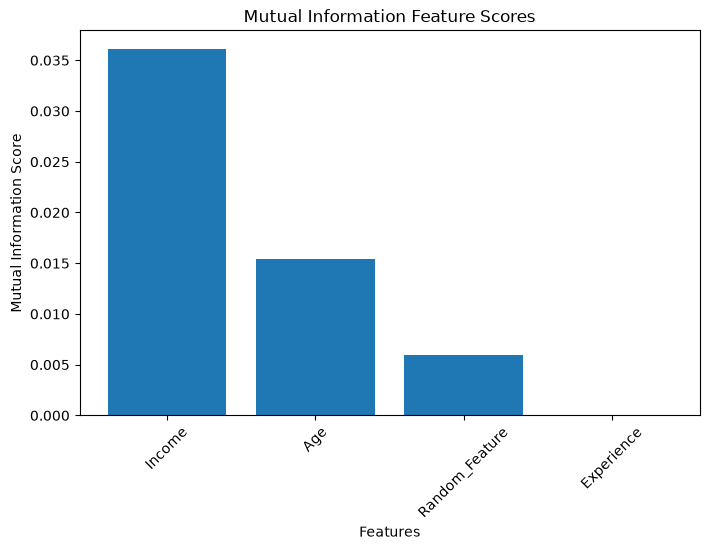

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    mi_results["Feature"],
    mi_results["Mutual_Information"]
)

plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Mutual Information Feature Scores")

plt.xticks(rotation=45)

plt.show()

## Selecting Top K Features

We can select the top K features based on their Mutual Information scores.

For example:

K = 2

This means we want to keep the two features with the highest Mutual
Information scores.

In [7]:
from sklearn.feature_selection import SelectKBest

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=2
)

X_selected = selector.fit_transform(X, y)

X_selected.shape

(300, 2)

In [8]:
selected_features = X.columns[
    selector.get_support()
]

selected_features

Index(['Income', 'Random_Feature'], dtype='str')

In [9]:
X_selected_df = X[selected_features]

X_selected_df.head()

,Income,Random_Feature
0,59790,0.086590
1,25600,-0.155677
2,60764,1.167782
3,94543,0.254421
4,65714,0.337603


## Interpreting Mutual Information Scores

Mutual Information scores are non-negative.

A score close to:

0 → Very little or no dependency

Higher score → Stronger dependency

Important:

There is no universal threshold such as 0.05 or 0.5 that always
determines whether a feature should be selected.

The scores are mainly useful for comparing features within the same
dataset and calculation.

## Mutual Information for Regression

When the target is continuous, we use:

`mutual_info_regression`

For example:

House Features → House Price

House Price is a continuous target, so Mutual Information for regression
should be used.

In [10]:
from sklearn.feature_selection import mutual_info_regression

X_reg = pd.DataFrame({
    "Size": [500, 700, 900, 1200, 1500, 1800],
    "Bedrooms": [1, 2, 2, 3, 4, 5],
    "Age": [20, 15, 10, 8, 5, 2]
})

y_reg = np.array([
    50000,
    70000,
    90000,
    120000,
    160000,
    200000
])

mi_regression = mutual_info_regression(
    X_reg,
    y_reg,
    random_state=42
)

mi_regression

array([0.45      , 0.45      , 0.29722222])

In [11]:
mi_reg_results = pd.DataFrame({
    "Feature": X_reg.columns,
    "Mutual_Information": mi_regression
})

mi_reg_results.sort_values(
    "Mutual_Information",
    ascending=False
)

,Feature,Mutual_Information
0,Size,0.450000
1,Bedrooms,0.450000
2,Age,0.297222


## Classification vs Regression

The function depends on the type of target.

### Classification

Use:

`mutual_info_classif`

Example:

Spam → 0/1

Disease → 0/1

Customer Churn → 0/1

### Regression

Use:

`mutual_info_regression`

Example:

House Price

Salary

Temperature